# Universal Services Comparison

**Platforms Compared:** RocketSingh, HomeSewa, Tackles, BuildingSewa, GardenSewa

**Prepared for:** Sriyog Consulting | Date: July 2026

## Load and Prepare Data

In [1]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the dataset
df = pd.read_excel('Universal_Services_Comparison.xlsx', sheet_name='Universal Services')
df.head()

,#,Name of Services,Category,RocketSingh,HomeSewa,Tackles,BuildingSewa,GardenSewa
0,1,AC Cleaning,Appliance Repair and Maintenance,NaN,NaN,NaN,NaN,NaN
1,2,AC Maintenance,Appliance Repair and Maintenance,NaN,NaN,NaN,NaN,NaN
2,3,AC Services,Appliance Repair and Maintenance,Yes,Yes,NaN,Yes,NaN
3,4,AC Servicing,Appliance Repair and Maintenance,NaN,NaN,Yes,NaN,NaN
4,5,Aeroplane Cleaning,Cleaning Services,NaN,NaN,NaN,NaN,NaN


In [3]:
# Counting how many platforms offer each service
PLATFORMS = ['RocketSingh', 'HomeSewa', 'Tackles', 'BuildingSewa', 'GardenSewa']
df['Platform Count'] = df[PLATFORMS].apply(lambda r: (r == 'Yes').sum(), axis=1)
df.shape

(250, 9)

## Charts

### Chart 1 - Total Services Offered by Each Platform

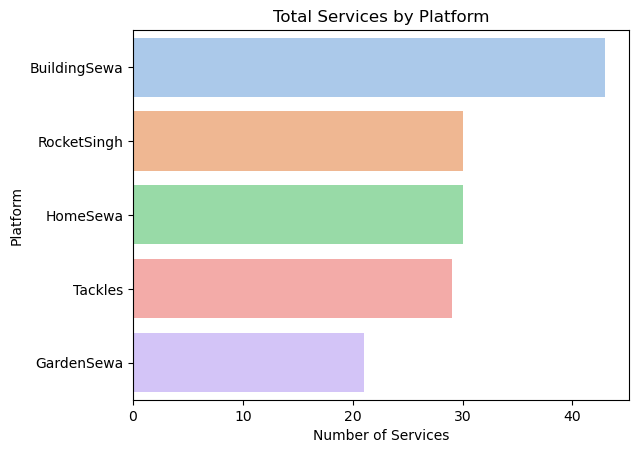

In [4]:
totals = pd.Series({p: (df[p] == 'Yes').sum() for p in PLATFORMS}). sort_values(ascending=False)
sns.barplot(x=totals.values, y=totals.index, hue=totals.index, palette='pastel', legend=False)
plt.title('Total Services by Platform')
plt.xlabel('Number of Services')
plt.ylabel('Platform')
plt.savefig("chart1.png", dpi=150, bbox_inches='tight')
plt.show()

**Insight:** BuildingSewa leads with 43 services, well ahead of RocketSingh and HomeSewa (30 each), Tackles (29), and GardenSewa (21), which has the narrowest offering.

### Chart 2 - Overall Service Distribution by Category 

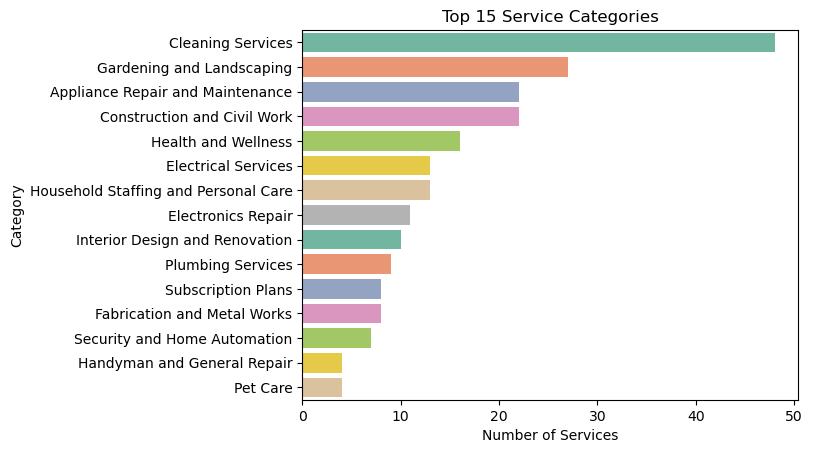

In [5]:
category_totals = df['Category'].value_counts().head(15)
sns.barplot(x=category_totals.values, y=category_totals.index, hue=category_totals.index, palette='Set2', legend=False)
plt.title('Top 15 Service Categories')
plt.xlabel('Number of Services')
plt.ylabel('Category')
plt.savefig("chart2.png", dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Cleaning Services is the most common category with 48 services, followed by Gardening and Landscaping (27) and both Appliance Repair and Construction and Civil Work (22 each).

### Chart 3 - Number of Categories Covered by Each Platform

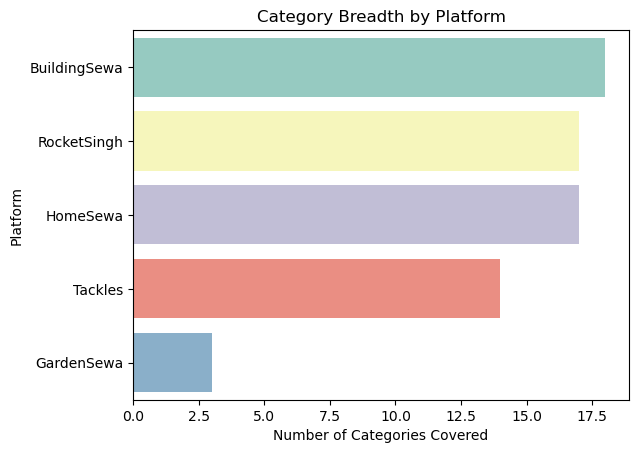

In [6]:
breadth = pd.Series({p: df.loc[df[p] == 'Yes', 'Category'].nunique() for p in PLATFORMS}).sort_values(ascending=False)
sns.barplot(x=breadth.values, y=breadth.index, hue=breadth.index, palette='Set3', legend=False)
plt.title('Category Breadth by Platform')
plt.xlabel('Number of Categories Covered')
plt.ylabel('Platform')
plt.savefig("chart3.png", dpi=150, bbox_inches='tight')
plt.show()

**Insight:** BuildingSewa covers the widest range at 18 categories, while GardenSewa is the most specialized, concentrated in just 3 categories.

### Chart 4 - Exclusive vs Shared Services per Platform

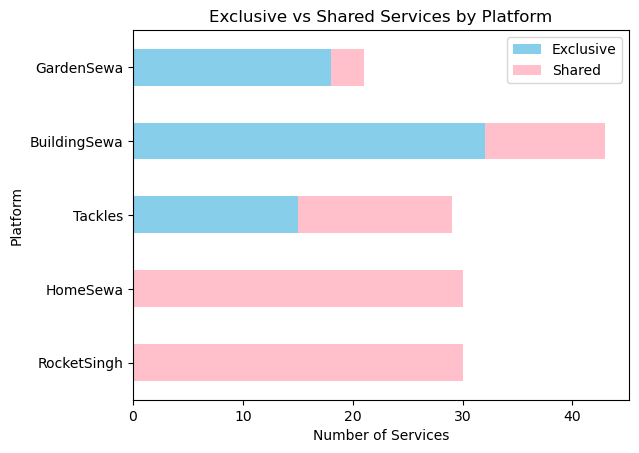

In [7]:
exclusive_shared = pd.DataFrame(index=PLATFORMS, columns=['Exclusive', 'Shared'])
for p in PLATFORMS:
    mask = df[p] == 'Yes'
    exclusive_shared.loc[p, 'Exclusive'] = ((df['Platform Count'] == 1) & mask).sum()
    exclusive_shared.loc[p, 'Shared'] = ((df['Platform Count'] > 1) & mask).sum()
exclusive_shared.astype(int).plot(kind='barh', stacked=True, color=['skyblue', 'pink'])
plt.title('Exclusive vs Shared Services by Platform')
plt.xlabel('Number of Services')
plt.ylabel('Platform')
plt.savefig("chart4.png", dpi=150, bbox_inches='tight')
plt.show()

**Insight:** RocketSingh and HomeSewa have zero exclusive services, every service they list is also offered by at least one other platform. BuildingSewa has the most exclusive services (32), reflecting its unique construction and civil-work niche.

### Chart 5 - Platform Overlap Matrix (Shared Services)

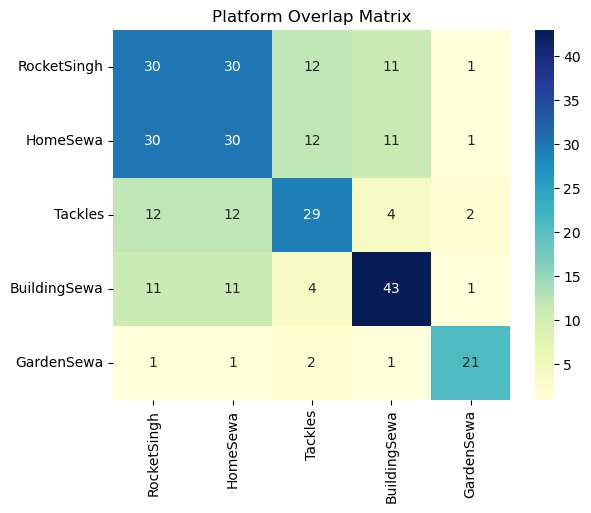

In [8]:
overlap = pd.DataFrame(index=PLATFORMS, columns=PLATFORMS, dtype=int)
for p1 in PLATFORMS:
    for p2 in PLATFORMS:
        overlap.loc[p1, p2] = int(((df[p1] == 'Yes') & (df[p2] == 'Yes')).sum())
overlap = overlap.astype(int)
sns.heatmap(overlap, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Platform Overlap Matrix')
plt.savefig("chart5.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** RocketSingh and HomeSewa show complete overlap (30 of 30 services shared), indicating an identical service catalog. GardenSewa overlaps minimally with every other platform, confirming its distinct gardening-only focus.

### Chart 6 - Platform Coverage Across Top 10 Categories

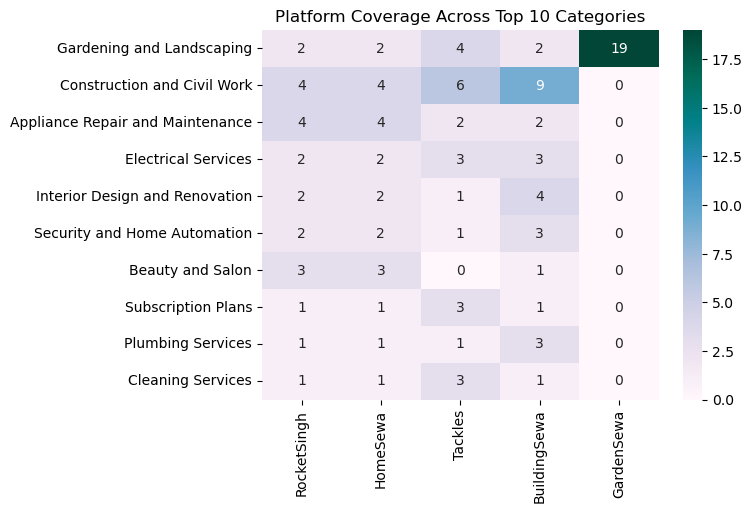

In [9]:
cat_platform = pd.DataFrame(index=df['Category'].unique(), columns=PLATFORMS, dtype=int)
for p in PLATFORMS:
    cat_platform[p] = df.groupby('Category')[p].apply(lambda s: (s == 'Yes').sum()).astype(int)
top_categories = cat_platform.loc[cat_platform.sum(axis=1).sort_values(ascending=False).index].head(10)
sns.heatmap(top_categories, annot=True, fmt='d', cmap='PuBuGn')
plt.title('Platform Coverage Across Top 10 Categories')
plt.savefig("chart6.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** Gardening and Landscaping is dominated almost entirely by GardenSewa, while Construction and Civil Work and Appliance Repair are led heavily by BuildingSewa, RocketSingh, and HomeSewa.

### Chart 7 - Market Fragmentation: How Many Platforms Offer Each Service

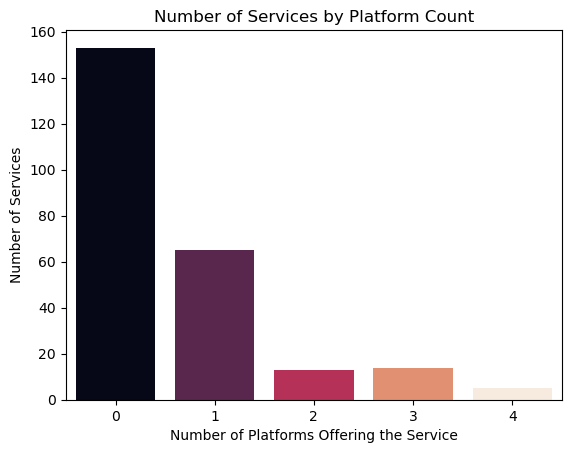

In [10]:
platform_count_dist = df['Platform Count'].value_counts().sort_index()
sns.barplot(x=platform_count_dist.index, y=platform_count_dist.values, hue=platform_count_dist.index, palette='rocket', legend=False)
plt.title('Number of Services by Platform Count')
plt.xlabel('Number of Platforms Offering the Service')
plt.ylabel('Number of Services')
plt.savefig("chart7.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** 153 of 250 services (61%) are not offered by any of the five platforms, pointing to a large gap in the current market. Among covered servuces, 65 are offered by exactly one platform, and only 5 services are offered by four platforms at once.

### Chart 8 - Market Share of Services by Platform

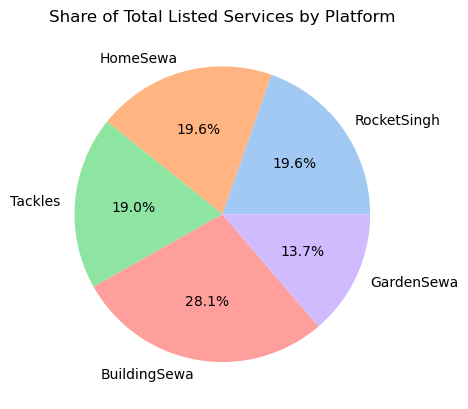

In [11]:
totals = pd.Series({p: (df[p] == 'Yes').sum() for p in PLATFORMS})
plt.pie(totals.values, labels=totals.index, autopct='%1.1f%%', colors=sns.color_palette('pastel', len(totals)))
plt.title('Share of Total Listed Services by Platform')
plt.savefig("chart8.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** BuildingSewa holds the largest share of listed services at 28.1%, while GardenSewa holds the smallest at 13.7%, among the 153 total service listings across the five platforms.

## Summary Table

In [12]:
summary = pd.DataFrame({
    'Total Services': totals,
    'Categories Covered': breadth,
    'Exclusive Services': exclusive_shared['Exclusive'],
    'Shared Services': exclusive_shared['Shared']
}).sort_values('Total Services', ascending=False)
summary

,Total Services,Categories Covered,Exclusive Services,Shared Services
BuildingSewa,43,18,32,11
HomeSewa,30,17,0,30
RocketSingh,30,17,0,30
Tackles,29,14,15,14
GardenSewa,21,3,18,3


## Key Findings

- **BuildingSewa** is the broadest platform: most total services (43), most categories covered (18), and the most exclusive services (32).
- **RocketSingh** and **HomeSewa** have an identical service catalog (30 services each, 100% overlap), suggesting they operate from the same underlying service list.
- **GardenSewa** is the most specialized platform, concentrated in just 3 categories, almost entirely Gardening and Landscaping.
- **Tackles** sits in the middle, with a fairly even split between exclusive (15) and shared (14) services.
- **Cleaning Services** is the single largest category in the market overall (48 services), but none of the five platforms cover it as their primary strength individually.
- Of the 250 total services identified in the market, 153 (61%) are not currently offered by any of the five platforms studied, indicating substantial white space for expansion.